# **Pregunta proyecto**
¿Que factores académicos y de habilidades predicen mejor si un estudiante universitario logrará empleabilidad?
# Preguntas de apoyo #
    "¿Qué variable académica tiene mayor asociación con la empleabilidad?",

    "¿Qué habilidades blandas diferencian más a los contratados de los que no?",

    "¿La empleabilidad y el salario varían según el género y la carrera?",

    "¿Qué tan grande es la diferencia del salario inicial entre estudiantes con y sin experiencia previa?",

    "¿Qué combinación de variables predice mejor en qué tipo de compañías van a quedar contratados?"



In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Cargar los datos
df = pd.read_csv("./origen/student_career_success_dataset.csv", sep=";")

# Ver dimensiones
print("Filas y columnas:", df.shape)

# Ver las primeras filas
print(df.head())

# Ver información de las variables
print(df.info())

# Revisar valores nulos
print(df.isnull().sum())

# Revisar duplicados
print("Duplicados:", df.duplicated().sum())

FileNotFoundError: [Errno 2] No such file or directory: './origen/student_career_success_dataset.csv'

In [ ]:
df.count()

Student_ID               50000
Age                      50000
Gender                   50000
University_Year          50000
Major                    50000
Attendance_Percentage    50000
Study_Hours_Per_Week     50000
CGPA                     50000
Academic_Performance     50000
Programming_Skill        50000
Projects_Completed       50000
Certifications           50000
Hackathons               50000
GitHub_Profile           50000
Internships              50000
Leadership_Experience    50000
LinkedIn_Profile         50000
Resume_Score             50000
Communication_Skills     50000
Teamwork                 50000
Problem_Solving          50000
English_Proficiency      50000
Interview_Score          50000
Employability_Score      49999
Placement_Status         50000
Company_Tier             50000
Career_Field             50000
Placement_Mode           50000
Starting_Salary_USD      50000
dtype: int64

In [ ]:
# Limpiar datos: eliminar duplicados y valores nulos #

In [ ]:

df = df.drop_duplicates()
df = df.dropna()

In [ ]:
df.count()


Student_ID               49999
Age                      49999
Gender                   49999
University_Year          49999
Major                    49999
Attendance_Percentage    49999
Study_Hours_Per_Week     49999
CGPA                     49999
Academic_Performance     49999
Programming_Skill        49999
Projects_Completed       49999
Certifications           49999
Hackathons               49999
GitHub_Profile           49999
Internships              49999
Leadership_Experience    49999
LinkedIn_Profile         49999
Resume_Score             49999
Communication_Skills     49999
Teamwork                 49999
Problem_Solving          49999
English_Proficiency      49999
Interview_Score          49999
Employability_Score      49999
Placement_Status         49999
Company_Tier             49999
Career_Field             49999
Placement_Mode           49999
Starting_Salary_USD      49999
dtype: int64

In [ ]:
# Que variable tiene mayor asociación con la empleabilidad
var_correlation_age = df["Employability_Score"].corr(df["Age"])
print("Correlación con Age:", var_correlation_age)


Correlación con Age: 0.0069111824223225616


In [ ]:
# Cargar o crear un DataFrame de ejemplo
dftest = pd.DataFrame({
    'edad': [25, 32, 47, 51, 22],
    'ingresos': [30000, 45000, 70000, 80000, 20000],
    'horas_estudio': [10, 5, 2, 1, 15]
})

# Calcular la matriz de correlación para todas las columnas numéricas
matriz_corr = dftest.corr(method='pearson')
print(matriz_corr)

                   edad  ingresos  horas_estudio
edad           1.000000  0.996235      -0.929090
ingresos       0.996235  1.000000      -0.954044
horas_estudio -0.929090 -0.954044       1.000000


In [11]:
# ¿Qué habilidades blandas diferencian más a los contratados de los que no?#

=== Correlación con la empleabilidad ===
Problem_Solving              0.348
Communication_Skills         0.275
Teamwork                     0.141
Leadership_Experience_bin    0.118
Name: Placement_bin, dtype: float64

=== Promedio por grupo (Placed vs Not Placed) ===
                  Communication_Skills  Teamwork  Problem_Solving  \
Placement_Status                                                    
Not Placed                        7.72      6.58             6.07   
Placed                            8.64      7.13             7.48   

                  Leadership_Experience_bin  
Placement_Status                             
Not Placed                             0.28  
Placed                                 0.42  

=== Diferencia (Placed - Not Placed) ===
Communication_Skills         0.92
Teamwork                     0.55
Problem_Solving              1.41
Leadership_Experience_bin    0.14
dtype: float64


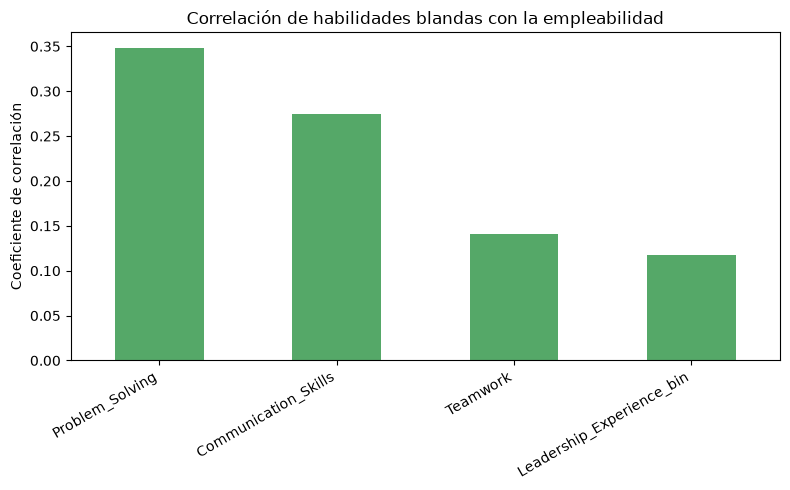


Conclusión: la habilidad blanda con mayor asociación es 'Problem_Solving' con una correlación de 0.348


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
 
# Carga data set
df = pd.read_csv('student_career_success_dataset.csv', sep=';')
 

df['Placement_bin'] = df['Placement_Status'].map({'Placed': 1, 'Not Placed': 0})
 
df['Leadership_Experience_bin'] = df['Leadership_Experience'].map({'Yes': 1, 'No': 0})
 
# Variables de habilidades blandas a evaluar
blandas = ['Communication_Skills', 'Teamwork', 'Problem_Solving', 'Leadership_Experience_bin']
 
# --- 1. Correlación de cada habilidad blanda con la empleabilidad ---
corr = df[blandas + ['Placement_bin']].corr()['Placement_bin'].drop('Placement_bin')
corr = corr.sort_values(ascending=False)
 
print("=== Correlación con la empleabilidad ===")
print(corr.round(3))
 
# --- 2. Comparación de medias: Placed vs Not Placed ---
comparacion = df.groupby('Placement_Status')[blandas].mean().round(2)
 
print("\n=== Promedio por grupo (Placed vs Not Placed) ===")
print(comparacion)
 
# --- 3. Diferencia entre grupos ---
diferencia = (comparacion.loc['Placed'] - comparacion.loc['Not Placed']).round(2)
 
print("\n=== Diferencia (Placed - Not Placed) ===")
print(diferencia)
 
# --- 4. Gráfico de barras de la correlación ---
plt.figure(figsize=(8, 5))
corr.plot(kind='bar', color='#55A868')
plt.title('Correlación de habilidades blandas con la empleabilidad')
plt.ylabel('Coeficiente de correlación')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('correlacion_blandas.png', dpi=150)
plt.show()
 
print(f"\nConclusión: la habilidad blanda con mayor asociación es '{corr.index[0]}' "
      f"con una correlación de {corr.iloc[0]:.3f}")

In [14]:
# **¿La empleabilidad y el salario varían según el género y la carrera?**

=== Empleabilidad promedio según género ===
Gender
Male      214.03
Female    213.97
Other     213.58
Name: Employability_Score, dtype: float64

=== Salario promedio según género ===
Gender
Female    88464.12
Male      88281.50
Other     87523.68
Name: Starting_Salary_USD, dtype: float64

=== Empleabilidad promedio según carrera ===
Major
Artificial Intelligence    226.63
Software Engineering       226.06
Computer Science           215.12
Cybersecurity              215.12
Data Science               214.96
Information Technology     203.49
Business Analytics         189.87
Electrical Engineering     189.43
Name: Employability_Score, dtype: float64

=== Salario promedio según carrera ===
Major
Artificial Intelligence    89531.40
Software Engineering       89347.29
Cybersecurity              88898.82
Data Science               88873.39
Computer Science           88700.75
Information Technology     87318.08
Business Analytics         83870.11
Electrical Engineering     83215.52
Name: Start

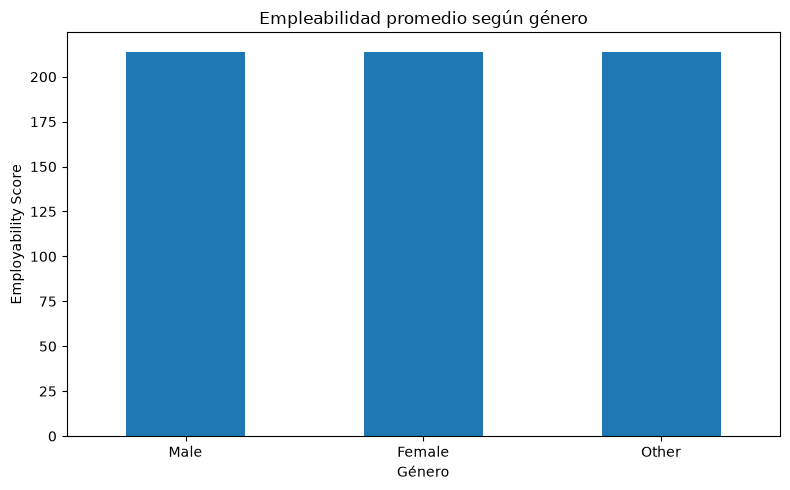

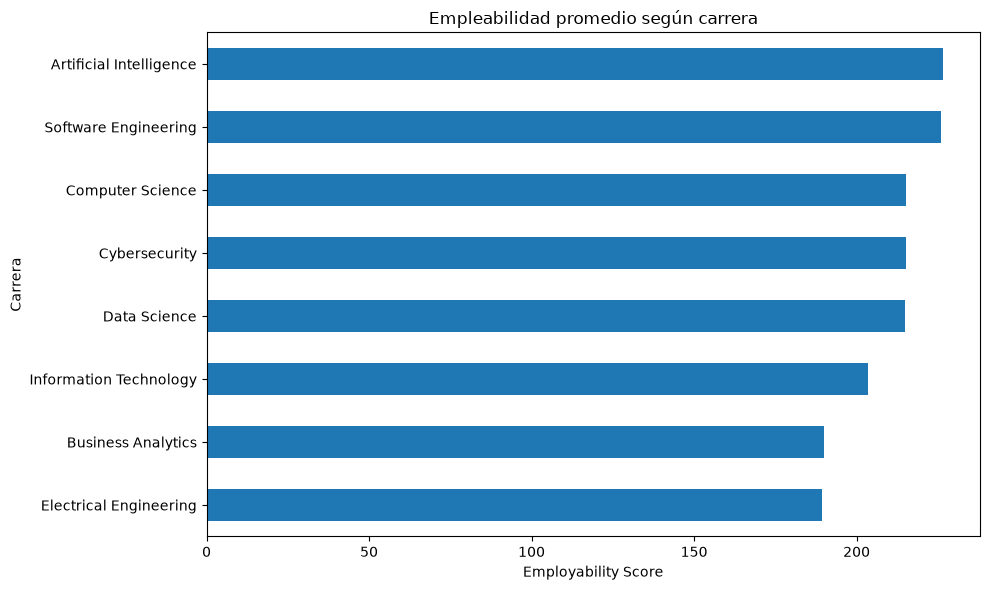


=== Conclusiones ===
La mayor empleabilidad promedio según género corresponde a 'Male'.
La mayor empleabilidad promedio según carrera corresponde a 'Artificial Intelligence'.
El mayor salario promedio entre los estudiantes contratados según género corresponde a 'Female'.
El mayor salario promedio entre los estudiantes contratados según carrera corresponde a 'Artificial Intelligence'.


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
 
# Cargar data set
df = pd.read_csv('student_career_success_dataset.csv', sep=';')
 
# --- 1. Empleabilidad promedio según género ---
empleabilidad_genero = (
    df.groupby('Gender')['Employability_Score']
    .mean()
    .sort_values(ascending=False)
)
 
print("=== Empleabilidad promedio según género ===")
print(empleabilidad_genero.round(2))
 
# --- 2. Salario promedio según género ---
# Se consideran solamente estudiantes contratados
salario_genero = (
    df[df['Placement_Status'] == 'Placed']
    .groupby('Gender')['Starting_Salary_USD']
    .mean()
    .sort_values(ascending=False)
)
 
print("\n=== Salario promedio según género ===")
print(salario_genero.round(2))
 
# --- 3. Empleabilidad promedio según carrera ---
empleabilidad_carrera = (
    df.groupby('Major')['Employability_Score']
    .mean()
    .sort_values(ascending=False)
)
 
print("\n=== Empleabilidad promedio según carrera ===")
print(empleabilidad_carrera.round(2))
 
# --- 4. Salario promedio según carrera ---
salario_carrera = (
    df[df['Placement_Status'] == 'Placed']
    .groupby('Major')['Starting_Salary_USD']
    .mean()
    .sort_values(ascending=False)
)
 
print("\n=== Salario promedio según carrera ===")
print(salario_carrera.round(2))
 
# --- 5. Gráfico de empleabilidad según género ---
plt.figure(figsize=(8, 5))
 
empleabilidad_genero.plot(
    kind='bar'
)
 
plt.title('Empleabilidad promedio según género')
plt.ylabel('Employability Score')
plt.xlabel('Género')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('empleabilidad_genero.png', dpi=150)
plt.show()
 
# --- 6. Gráfico de empleabilidad según carrera ---
plt.figure(figsize=(10, 6))
 
empleabilidad_carrera.sort_values().plot(
    kind='barh'
)
 
plt.title('Empleabilidad promedio según carrera')
plt.xlabel('Employability Score')
plt.ylabel('Carrera')
plt.tight_layout()
plt.savefig('empleabilidad_carrera.png', dpi=150)
plt.show()
 
# --- 7. Conclusiones automáticas ---
genero_mayor_empleabilidad = empleabilidad_genero.index[0]
carrera_mayor_empleabilidad = empleabilidad_carrera.index[0]
 
genero_mayor_salario = salario_genero.index[0]
carrera_mayor_salario = salario_carrera.index[0]
 
print("\n=== Conclusiones ===")
 
print(
    f"La mayor empleabilidad promedio según género corresponde a "
    f"'{genero_mayor_empleabilidad}'."
)
 
print(
    f"La mayor empleabilidad promedio según carrera corresponde a "
    f"'{carrera_mayor_empleabilidad}'."
)
 
print(
    f"El mayor salario promedio entre los estudiantes contratados "
    f"según género corresponde a '{genero_mayor_salario}'."
)
 
print(
    f"El mayor salario promedio entre los estudiantes contratados "
    f"según carrera corresponde a '{carrera_mayor_salario}'."
)

In [ ]:
¿Qué tan grande es la diferencia del salario inicial entre estudiantes con y sin experiencia previa?

=== Cantidad de estudiantes según experiencia previa ===
Experiencia_Previa
Con experiencia    49941
Sin experiencia       59
Name: count, dtype: int64

=== Salario promedio según experiencia previa ===
Experiencia_Previa
Con experiencia    88360.91
Sin experiencia    37983.00
Name: Starting_Salary_USD, dtype: float64

=== Diferencia salarial ===
50377.91 USD

=== Diferencia porcentual ===
132.63%


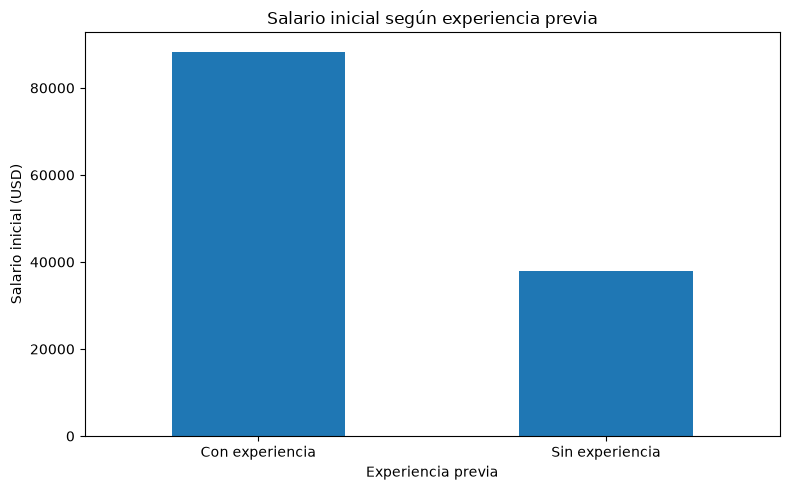


Conclusión: los estudiantes con experiencia previa presentan un salario inicial promedio superior en 50377.91 USD, equivalente a 132.63% frente a los estudiantes sin experiencia.


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
 
# Cargar data set
df = pd.read_csv('student_career_success_dataset.csv', sep=';')
 
# --- 1. Crear variable de experiencia previa ---
df['Experiencia_Previa'] = df['Internships'].apply(
    lambda x: 'Con experiencia' if x > 0 else 'Sin experiencia'
)
 
# --- 2. Cantidad de estudiantes por grupo ---
cantidad_experiencia = df['Experiencia_Previa'].value_counts()
 
print("=== Cantidad de estudiantes según experiencia previa ===")
print(cantidad_experiencia)
 
# --- 3. Salario promedio por experiencia ---
# Se consideran únicamente estudiantes contratados
salario_experiencia = (
    df[df['Placement_Status'] == 'Placed']
    .groupby('Experiencia_Previa')['Starting_Salary_USD']
    .mean()
    .sort_values(ascending=False)
)
 
print("\n=== Salario promedio según experiencia previa ===")
print(salario_experiencia.round(2))
 
# --- 4. Diferencia salarial ---
diferencia_salario = (
    salario_experiencia['Con experiencia'] -
    salario_experiencia['Sin experiencia']
)
 
print(
    f"\n=== Diferencia salarial ===\n"
    f"{diferencia_salario:.2f} USD"
)
 
# --- 5. Diferencia porcentual ---
porcentaje_diferencia = (
    diferencia_salario /
    salario_experiencia['Sin experiencia']
) * 100
 
print(
    f"\n=== Diferencia porcentual ===\n"
    f"{porcentaje_diferencia:.2f}%"
)
 
# --- 6. Gráfico de salario promedio ---
plt.figure(figsize=(8, 5))
 
salario_experiencia.plot(
    kind='bar'
)
 
plt.title('Salario inicial según experiencia previa')
plt.ylabel('Salario inicial (USD)')
plt.xlabel('Experiencia previa')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('salario_experiencia.png', dpi=150)
plt.show()
 
# --- 7. Conclusión automática ---
if diferencia_salario > 0:
    print(
        f"\nConclusión: los estudiantes con experiencia previa "
        f"presentan un salario inicial promedio superior en "
        f"{diferencia_salario:.2f} USD, equivalente a "
        f"{porcentaje_diferencia:.2f}% frente a los estudiantes "
        f"sin experiencia."
    )
else:
    print(
        f"\nConclusión: los estudiantes sin experiencia previa "
        f"presentan un salario inicial promedio superior en "
        f"{abs(diferencia_salario):.2f} USD.")

In [24]:
# Qué combinación de variables predice mejor en qué tipo de compañías van a quedar contratados #

=== Correlación con conseguir Tier 1 ===
Resume_Score             0.661
Interview_Score          0.434
Internships              0.432
Programming_Skill        0.377
Problem_Solving          0.344
Projects_Completed       0.341
Communication_Skills     0.272
CGPA                     0.247
Attendance_Percentage    0.174
Teamwork                 0.133
Study_Hours_Per_Week     0.114
Name: Es_Tier1, dtype: float64

=== Promedio por grupo ===
            CGPA  Attendance_Percentage  Study_Hours_Per_Week  \
Tier 2 o 3  2.84                  75.06                 18.53   
Tier 1      3.16                  82.73                 22.23   

            Communication_Skills  Teamwork  Problem_Solving  \
Tier 2 o 3                  7.08      6.18             5.12   
Tier 1                      8.72      7.17             7.60   

            Programming_Skill  Projects_Completed  Internships  Resume_Score  \
Tier 2 o 3               5.13                5.56         2.59         82.50   
Tier 1       

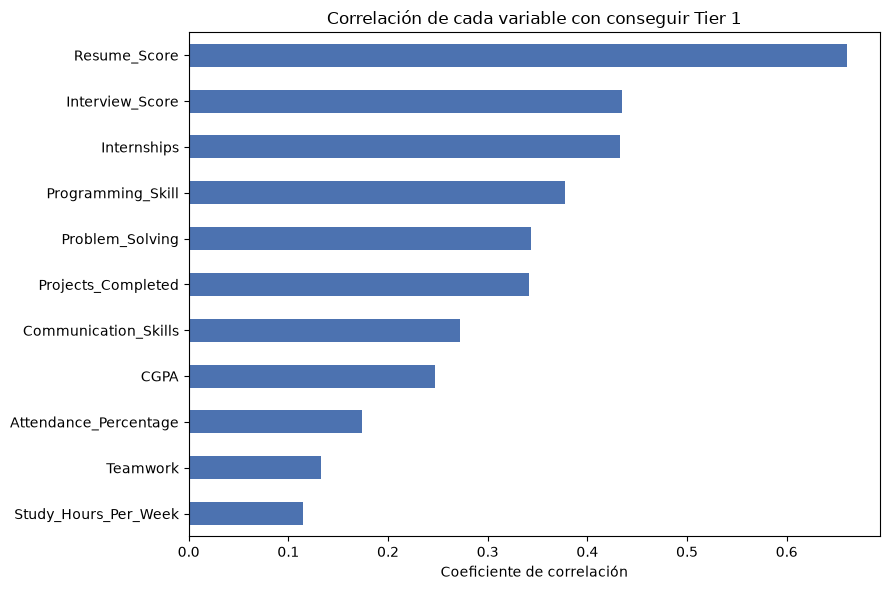


Conclusión: la variable con mayor asociación a conseguir una empresa Tier 1 es 'Resume_Score' con una correlación de 0.661, seguida de 'Interview_Score' (0.434).


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
 
# Cargar el dataset 
df = pd.read_csv('student_career_success_dataset.csv', sep=';')
 
# Solo estudiantes SÍ colocados (para analizar el TIER, necesitan tener empresa)
df_colocados = df[df['Placement_Status'] == 'Placed'].copy()
 
# Crear variable binaria: 1 si consiguió Tier 1, 0 si consiguió Tier 2 o Tier 3
df_colocados['Es_Tier1'] = df_colocados['Company_Tier'].apply(lambda x: 1 if x == 'Tier 1' else 0)
 
# Variables a evaluar (académicas, habilidades y proceso de postulación)
variables = [
    'CGPA', 'Attendance_Percentage', 'Study_Hours_Per_Week',
    'Communication_Skills', 'Teamwork', 'Problem_Solving',
    'Programming_Skill', 'Projects_Completed', 'Internships',
    'Resume_Score', 'Interview_Score'
]
 
# --- 1. Correlación de cada variable con conseguir Tier 1 ---
corr = df_colocados[variables + ['Es_Tier1']].corr()['Es_Tier1'].drop('Es_Tier1')
corr = corr.sort_values(ascending=False)
 
print("=== Correlación con conseguir Tier 1 ===")
print(corr.round(3))
 
# --- 2. Comparación de medias: Tier 1 vs (Tier 2 + Tier 3) ---
comparacion = df_colocados.groupby('Es_Tier1')[variables].mean().round(2)
comparacion.index = ['Tier 2 o 3', 'Tier 1']
 
print("\n=== Promedio por grupo ===")
print(comparacion)
 
# --- 3. Diferencia entre grupos ---
diferencia = (comparacion.loc['Tier 1'] - comparacion.loc['Tier 2 o 3']).round(2)
 
print("\n=== Diferencia (Tier 1 - Tier 2/3) ===")
print(diferencia)
 
# --- 4. Gráfico ---
plt.figure(figsize=(9, 6))
corr.plot(kind='barh', color='#4C72B0')
plt.title('Correlación de cada variable con conseguir Tier 1')
plt.xlabel('Coeficiente de correlación')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('correlacion_tier1.png', dpi=150)
plt.show()
 
print(f"\nConclusión: la variable con mayor asociación a conseguir una empresa Tier 1 "
      f"es '{corr.index[0]}' con una correlación de {corr.iloc[0]:.3f}, seguida de "
      f"'{corr.index[1]}' ({corr.iloc[1]:.3f}).")

=== Medidas de tendencia central ===
                        Media  Mediana    Moda
Attendance_Percentage   81.41    82.00   83.00
Study_Hours_Per_Week    21.53    21.00   21.00
CGPA                     3.11     3.11    3.15
Programming_Skill        7.14     7.00    7.00
Projects_Completed       8.62     9.00    9.00
Certifications           1.72     2.00    2.00
Hackathons               3.09     3.00    3.00
Internships              4.05     4.00    5.00
Resume_Score            96.05   100.00  100.00
Communication_Skills     8.44     9.00   10.00
Teamwork                 7.01     7.00    7.00
Problem_Solving          7.18     7.00    7.00
Interview_Score         77.52    78.00   79.00
Employability_Score    213.99   217.25  230.50

=== Medidas de dispersión ===
                       Mínimo  Máximo   Rango  Varianza  Desviación_Estándar
Attendance_Percentage    50.0  100.00   50.00     94.27                 9.71
Study_Hours_Per_Week      5.0   45.00   40.00     48.65                 6

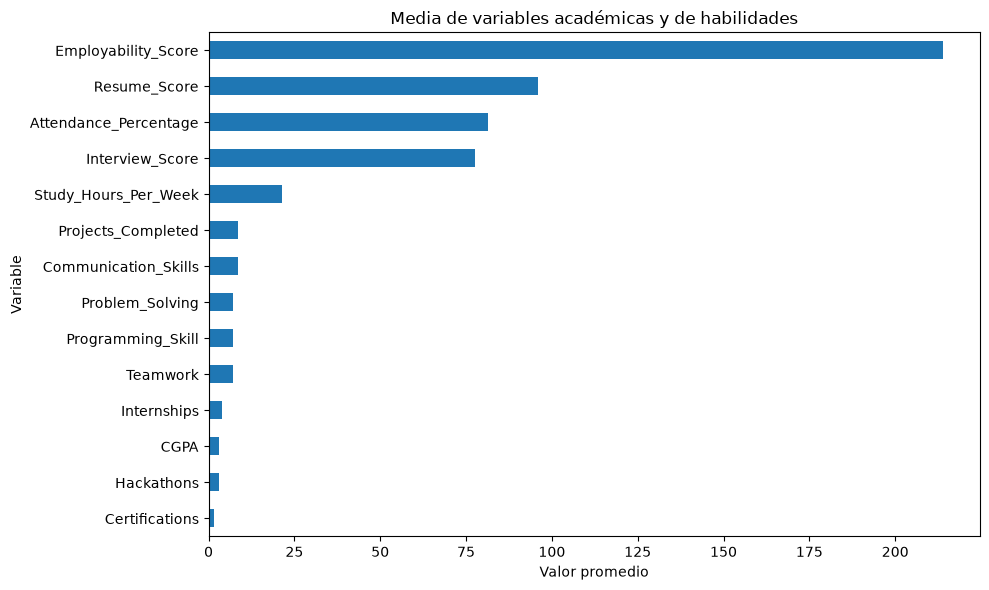

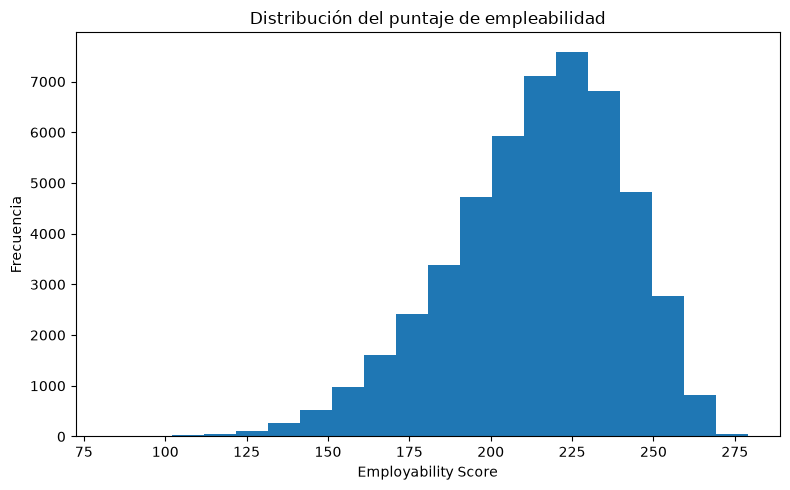

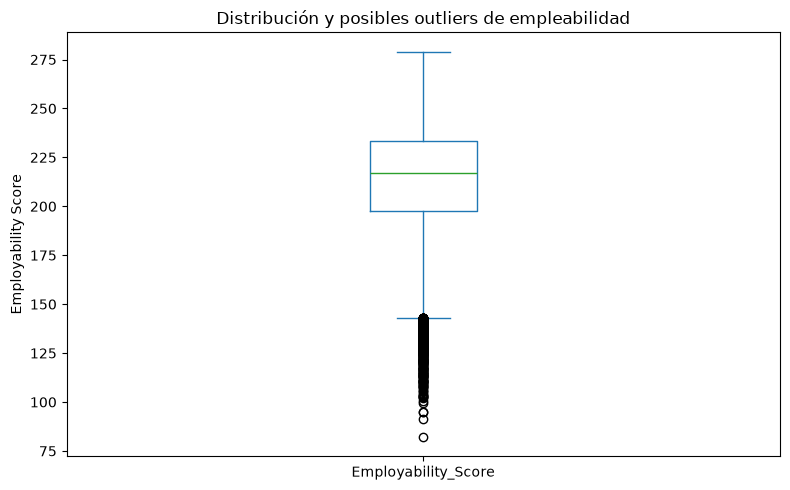

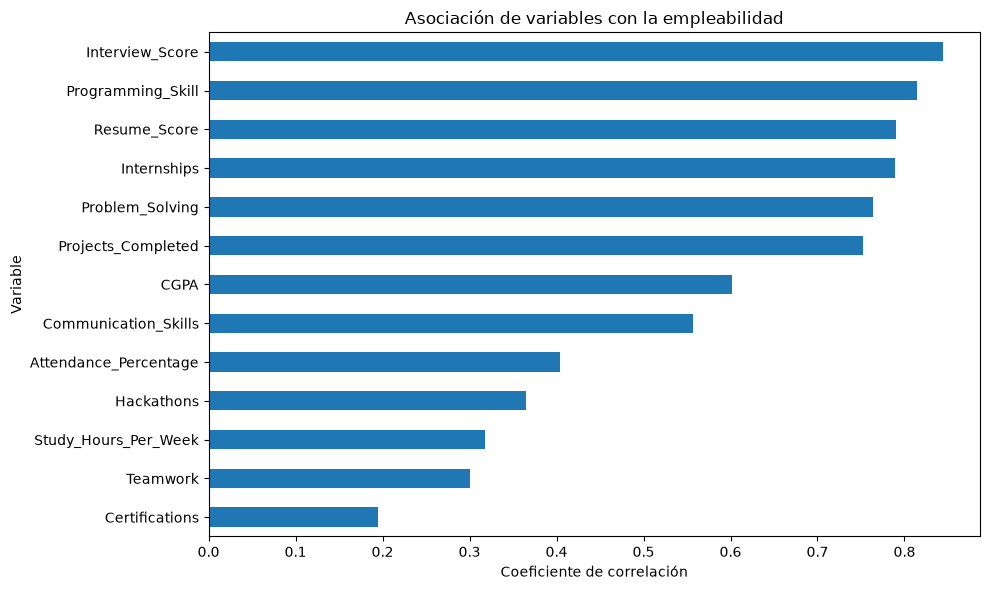


=== Conclusiones ===
La variable con mayor asociación positiva con la empleabilidad es 'Interview_Score', con una correlación de 0.845.
La variable con menor asociación con la empleabilidad es 'Certifications', con una correlación de 0.195.
La variable que presenta mayor cantidad de posibles outliers es 'Resume_Score', con 6354 casos.
El promedio del puntaje de empleabilidad es 213.99, mientras que la mediana es 217.25.
La desviación estándar del puntaje de empleabilidad es 26.82.
La media es inferior a la mediana, lo que puede indicar la presencia de algunos valores bajos en la distribución.


<function matplotlib.pyplot.show(close=None, block=None)>

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
 
# Cargar data set
df = pd.read_csv('student_career_success_dataset.csv', sep=';')
 
# --- 1. Variables a analizar ---
variables = [
    'Attendance_Percentage',
    'Study_Hours_Per_Week',
    'CGPA',
    'Programming_Skill',
    'Projects_Completed',
    'Certifications',
    'Hackathons',
    'Internships',
    'Resume_Score',
    'Communication_Skills',
    'Teamwork',
    'Problem_Solving',
    'Interview_Score',
    'Employability_Score'
]
 
# --- 2. Medidas de tendencia central ---
media = df[variables].mean()
mediana = df[variables].median()
moda = df[variables].mode().iloc[0]
 
tendencia_central = pd.DataFrame({
    'Media': media,
    'Mediana': mediana,
    'Moda': moda
})
 
print("=== Medidas de tendencia central ===")
print(tendencia_central.round(2))
 
# --- 3. Medidas de dispersión ---
minimo = df[variables].min()
maximo = df[variables].max()
rango = maximo - minimo
varianza = df[variables].var()
desviacion_estandar = df[variables].std()
 
dispersion = pd.DataFrame({
    'Mínimo': minimo,
    'Máximo': maximo,
    'Rango': rango,
    'Varianza': varianza,
    'Desviación_Estándar': desviacion_estandar
})
 
print("\n=== Medidas de dispersión ===")
print(dispersion.round(2))
 
# --- 4. Análisis específico de empleabilidad ---
empleabilidad = df['Employability_Score']
 
print("\n=== Análisis del Employability Score ===")
 
print(
    f"Media: {empleabilidad.mean():.2f}"
)
 
print(
    f"Mediana: {empleabilidad.median():.2f}"
)
 
print(
    f"Moda: {empleabilidad.mode().iloc[0]:.2f}"
)
 
print(
    f"Mínimo: {empleabilidad.min():.2f}"
)
 
print(
    f"Máximo: {empleabilidad.max():.2f}"
)
 
print(
    f"Rango: {(empleabilidad.max() - empleabilidad.min()):.2f}"
)
 
print(
    f"Varianza: {empleabilidad.var():.2f}"
)
 
print(
    f"Desviación estándar: {empleabilidad.std():.2f}"
)
 
# --- 5. Comparación de variables con la empleabilidad ---
correlaciones = (
    df[variables]
    .corr()['Employability_Score']
    .drop('Employability_Score')
    .sort_values(ascending=False)
)
 
print("\n=== Correlación de las variables con la empleabilidad ===")
print(correlaciones.round(3))
 
# --- 6. Identificación de outliers ---
Q1 = df[variables].quantile(0.25)
Q3 = df[variables].quantile(0.75)
 
IQR = Q3 - Q1
 
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
 
outliers = (
    (df[variables] < limite_inferior) |
    (df[variables] > limite_superior)
).sum()
 
print("\n=== Cantidad de posibles outliers ===")
print(outliers.sort_values(ascending=False))
 
# --- 7. Porcentaje de outliers ---
porcentaje_outliers = (
    outliers / len(df)
) * 100
 
print("\n=== Porcentaje de posibles outliers ===")
print(porcentaje_outliers.sort_values(ascending=False).round(2))
 
# --- 8. Gráfico de media de las variables ---
plt.figure(figsize=(10, 6))
 
media.sort_values().plot(
    kind='barh'
)
 
plt.title('Media de variables académicas y de habilidades')
plt.xlabel('Valor promedio')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig('media_variables.png', dpi=150)
plt.show()
 
# --- 9. Gráfico de distribución de empleabilidad ---
plt.figure(figsize=(8, 5))
 
df['Employability_Score'].plot(
    kind='hist',
    bins=20
)
 
plt.title('Distribución del puntaje de empleabilidad')
plt.xlabel('Employability Score')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.savefig('distribucion_empleabilidad.png', dpi=150)
plt.show()
 
# --- 10. Gráfico de posibles outliers ---
plt.figure(figsize=(8, 5))
 
df['Employability_Score'].plot(
    kind='box'
)
 
plt.title('Distribución y posibles outliers de empleabilidad')
plt.ylabel('Employability Score')
plt.tight_layout()
plt.savefig('outliers_empleabilidad.png', dpi=150)
plt.show()
 
# --- 11. Gráfico de correlación con la empleabilidad ---
plt.figure(figsize=(10, 6))
 
correlaciones.sort_values().plot(
    kind='barh'
)
 
plt.title('Asociación de variables con la empleabilidad')
plt.xlabel('Coeficiente de correlación')
plt.ylabel('Variable')
plt.tight_layout()
plt.savefig('correlacion_empleabilidad.png', dpi=150)
plt.show()
 
# --- 12. Conclusiones automáticas ---
variable_mayor_correlacion = correlaciones.index[0]
valor_mayor_correlacion = correlaciones.iloc[0]
 
variable_menor_correlacion = correlaciones.index[-1]
valor_menor_correlacion = correlaciones.iloc[-1]
 
variable_mas_outliers = outliers.idxmax()
cantidad_mas_outliers = outliers.max()
 
print("\n=== Conclusiones ===")
 
print(
    f"La variable con mayor asociación positiva con la empleabilidad "
    f"es '{variable_mayor_correlacion}', con una correlación de "
    f"{valor_mayor_correlacion:.3f}."
)
 
print(
    f"La variable con menor asociación con la empleabilidad "
    f"es '{variable_menor_correlacion}', con una correlación de "
    f"{valor_menor_correlacion:.3f}."
)
 
print(
    f"La variable que presenta mayor cantidad de posibles outliers "
    f"es '{variable_mas_outliers}', con {cantidad_mas_outliers} casos."
)
 
print(
    f"El promedio del puntaje de empleabilidad es "
    f"{empleabilidad.mean():.2f}, mientras que la mediana es "
    f"{empleabilidad.median():.2f}."
)
 
print(
    f"La desviación estándar del puntaje de empleabilidad es "
    f"{empleabilidad.std():.2f}."
)
 
if empleabilidad.mean() > empleabilidad.median():
    print(
        "La media es superior a la mediana, lo que puede indicar "
        "la presencia de algunos valores altos en la distribución."
    )
 
elif empleabilidad.mean() < empleabilidad.median():
    print(
        "La media es inferior a la mediana, lo que puede indicar "
        "la presencia de algunos valores bajos en la distribución."
    )
 
else:
    print(
        "La media y la mediana son iguales, lo que indica una "
        "distribución equilibrada alrededor del centro."
    )
 
plt.show
 

In [30]:
# Identificar outliers, relaciones o posibles hipótesis basadas en los valores #

=== CANTIDAD DE OUTLIERS POR VARIABLE ===
Resume_Score             6354
Projects_Completed        806
Employability_Score       545
Interview_Score           490
CGPA                      267
Attendance_Percentage     249
Study_Hours_Per_Week      244
Problem_Solving           192
Programming_Skill          88
Certifications             29
Teamwork                   24
Communication_Skills        0
Internships                 0
dtype: int64

=== PORCENTAJE DE OUTLIERS ===
Resume_Score             12.71
Projects_Completed        1.61
Employability_Score       1.09
Interview_Score           0.98
CGPA                      0.53
Attendance_Percentage     0.50
Study_Hours_Per_Week      0.49
Problem_Solving           0.38
Programming_Skill         0.18
Certifications            0.06
Teamwork                  0.05
Communication_Skills      0.00
Internships               0.00
dtype: float64

La variable con mayor cantidad de posibles outliers es 'Resume_Score', con 6354 casos.


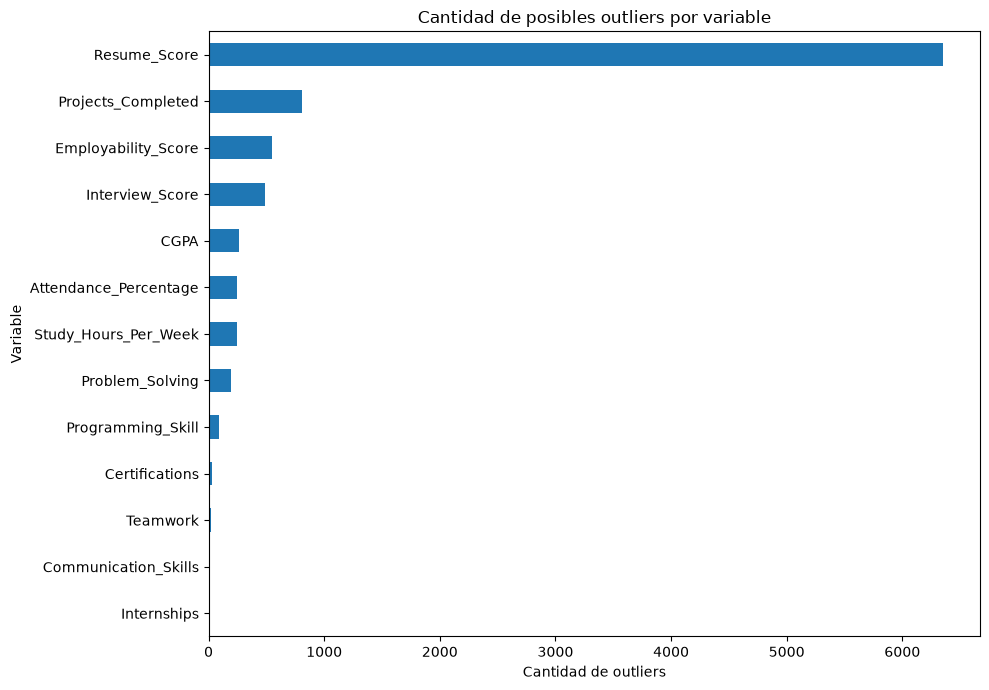


=== RELACIONES CON EMPLOYABILITY SCORE ===
Interview_Score          0.845
Programming_Skill        0.814
Resume_Score             0.791
Internships              0.790
Problem_Solving          0.764
Projects_Completed       0.752
CGPA                     0.601
Communication_Skills     0.557
Attendance_Percentage    0.404
Study_Hours_Per_Week     0.317
Teamwork                 0.301
Certifications           0.195
Name: Employability_Score, dtype: float64

La variable con mayor relación positiva con la empleabilidad es 'Interview_Score', con una correlación de 0.845.
La relación negativa más fuerte corresponde a 'Certifications', con una correlación de 0.195.


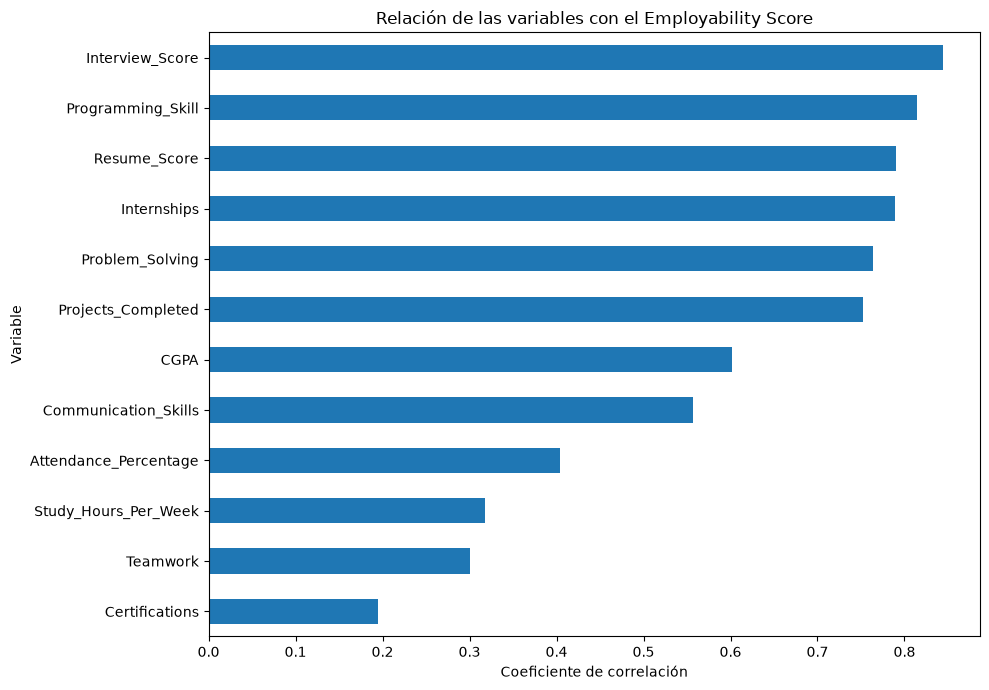

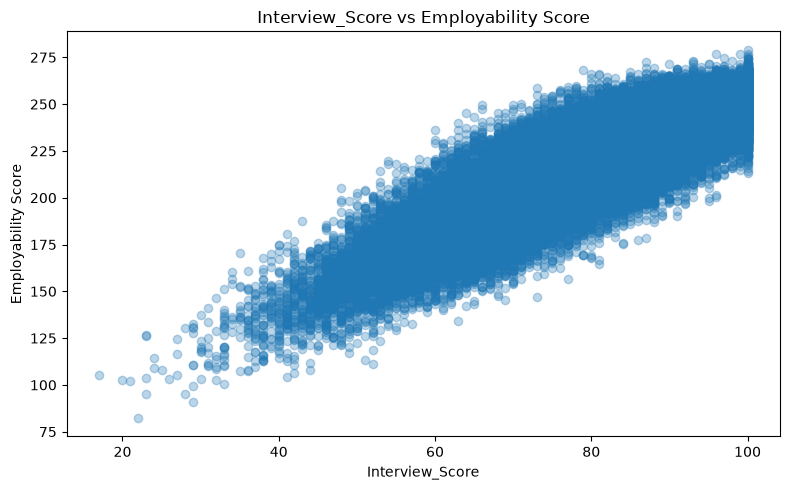


=== POSIBLES HIPÓTESIS ===
H1: Un mayor nivel de 'Interview_Score' podría estar relacionado con un mayor nivel de empleabilidad.
H2: Los estudiantes con mejores resultados académicos y mayores habilidades profesionales podrían presentar mayores niveles de empleabilidad.
H3: Los valores atípicos identificados podrían influir en los promedios y en la interpretación de los resultados.

=== CONCLUSIÓN ===
El análisis permitió identificar posibles valores atípicos y relaciones entre las variables. La variable con mayor relación con la empleabilidad fue 'Interview_Score', mientras que 'Resume_Score' presentó la mayor cantidad de posibles outliers.
Estos resultados permiten plantear hipótesis sobre los factores que pueden estar relacionados con la empleabilidad de los estudiantes. Las hipótesis pueden ser comprobadas mediante análisis estadísticos posteriores.


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
 
# ============================================================
# PUNTO: OUTLIERS, RELACIONES Y POSIBLES HIPÓTESIS
# ============================================================
 
# --- 1. Seleccionar las variables a analizar ---
variables = [
    'Attendance_Percentage',
    'Study_Hours_Per_Week',
    'CGPA',
    'Programming_Skill',
    'Projects_Completed',
    'Certifications',
    'Internships',
    'Resume_Score',
    'Communication_Skills',
    'Teamwork',
    'Problem_Solving',
    'Interview_Score',
    'Employability_Score'
]
 
# --- 2. Identificar outliers mediante el método IQR ---
Q1 = df[variables].quantile(0.25)
Q3 = df[variables].quantile(0.75)
 
IQR = Q3 - Q1
 
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
 
outliers = (
    (df[variables] < limite_inferior) |
    (df[variables] > limite_superior)
).sum()
 
print("=== CANTIDAD DE OUTLIERS POR VARIABLE ===")
print(outliers.sort_values(ascending=False))
 
# --- 3. Calcular porcentaje de outliers ---
porcentaje_outliers = (
    outliers / len(df)
) * 100
 
print("\n=== PORCENTAJE DE OUTLIERS ===")
print(porcentaje_outliers.sort_values(ascending=False).round(2))
 
# --- 4. Identificar la variable con más outliers ---
variable_mas_outliers = outliers.idxmax()
cantidad_mas_outliers = outliers.max()
 
print(
    f"\nLa variable con mayor cantidad de posibles outliers "
    f"es '{variable_mas_outliers}', con "
    f"{cantidad_mas_outliers} casos."
)
 
# --- 5. Gráfico de outliers ---
plt.figure(figsize=(10, 7))
 
outliers.sort_values(ascending=True).plot(
    kind='barh'
)
 
plt.title('Cantidad de posibles outliers por variable')
plt.xlabel('Cantidad de outliers')
plt.ylabel('Variable')
 
plt.tight_layout()
 
plt.savefig(
    'outliers_variables.png',
    dpi=150
)
 
plt.show()
 
# --- 6. Analizar relaciones con la empleabilidad ---
correlaciones = (
    df[variables]
    .corr()['Employability_Score']
    .drop('Employability_Score')
    .sort_values(ascending=False)
)
 
print("\n=== RELACIONES CON EMPLOYABILITY SCORE ===")
print(correlaciones.round(3))
 
# --- 7. Identificar la relación positiva más fuerte ---
variable_mayor_relacion = correlaciones.index[0]
valor_mayor_relacion = correlaciones.iloc[0]
 
print(
    f"\nLa variable con mayor relación positiva con "
    f"la empleabilidad es '{variable_mayor_relacion}', "
    f"con una correlación de {valor_mayor_relacion:.3f}."
)
 
# --- 8. Identificar la relación negativa más fuerte ---
variable_menor_relacion = correlaciones.index[-1]
valor_menor_relacion = correlaciones.iloc[-1]
 
print(
    f"La relación negativa más fuerte corresponde a "
    f"'{variable_menor_relacion}', con una correlación de "
    f"{valor_menor_relacion:.3f}."
)
 
# --- 9. Gráfico de relaciones ---
plt.figure(figsize=(10, 7))
 
correlaciones.sort_values().plot(
    kind='barh'
)
 
plt.title(
    'Relación de las variables con el Employability Score'
)
 
plt.xlabel('Coeficiente de correlación')
plt.ylabel('Variable')
 
plt.tight_layout()
 
plt.savefig(
    'relaciones_empleabilidad.png',
    dpi=150
)
 
plt.show()
 
# --- 10. Gráfico de dispersión ---
plt.figure(figsize=(8, 5))
 
plt.scatter(
    df[variable_mayor_relacion],
    df['Employability_Score'],
    alpha=0.3
)
 
plt.title(
    f'{variable_mayor_relacion} vs Employability Score'
)
 
plt.xlabel(variable_mayor_relacion)
plt.ylabel('Employability Score')
 
plt.tight_layout()
 
plt.savefig(
    'relacion_mayor_empleabilidad.png',
    dpi=150
)
 
plt.show()
 
# --- 11. Posibles hipótesis ---
print("\n=== POSIBLES HIPÓTESIS ===")
 
print(
    f"H1: Un mayor nivel de '{variable_mayor_relacion}' "
    f"podría estar relacionado con un mayor nivel de "
    f"empleabilidad."
)
 
print(
    "H2: Los estudiantes con mejores resultados académicos "
    "y mayores habilidades profesionales podrían presentar "
    "mayores niveles de empleabilidad."
)
 
print(
    "H3: Los valores atípicos identificados podrían influir "
    "en los promedios y en la interpretación de los resultados."
)
 
# --- 12. Conclusión general ---
print("\n=== CONCLUSIÓN ===")
 
print(
    f"El análisis permitió identificar posibles valores atípicos "
    f"y relaciones entre las variables. La variable con mayor "
    f"relación con la empleabilidad fue "
    f"'{variable_mayor_relacion}', mientras que "
    f"'{variable_mas_outliers}' presentó la mayor cantidad "
    f"de posibles outliers."
)
 
print(
    "Estos resultados permiten plantear hipótesis sobre los "
    "factores que pueden estar relacionados con la empleabilidad "
    "de los estudiantes. Las hipótesis pueden ser comprobadas "
    "mediante análisis estadísticos posteriores.")